In [1]:
import numpy as np
import pandas as pd
import pickle

from tqdm import tqdm
from config import config
from xgboost import XGBClassifier
from matplotlib import pyplot as plt
from scipy.ndimage import uniform_filter
from joblib import Parallel, delayed
from utils import (
    build_metadata, plot_class_distribution, split_metadata,
    print_split_summary, preprocess_img, sample_pixels,
    encode_labels, decode_labels, count_by_class, evaluate_split,
)

In [2]:
def local_mean_std(x, size=3):
    mean = uniform_filter(x, size=size)
    mean_sq = uniform_filter(x * x, size=size)
    var = np.maximum(mean_sq - mean * mean, 0.0)
    std = np.sqrt(var)
    return mean, std

def normalized_diff(a, b, eps=1e-6):
    return (a - b) / (a + b + eps)

def extract_features(img):
    b_raw = img.astype(np.float32)

    blue = b_raw[1]
    green = b_raw[2]
    red = b_raw[3]
    nir = b_raw[7]
    swir1 = b_raw[10]
    swir2 = b_raw[11]

    h, w = red.shape

    bands_mean = np.mean(b_raw, axis=0)
    bands_std = np.std(b_raw, axis=0)
    brightness = np.mean(b_raw[[1, 2, 3]], axis=0)
    visible_std = np.std(b_raw[[1, 2, 3]], axis=0)

    ndvi = normalized_diff(nir, red)
    ndwi = normalized_diff(green, nir)
    mndwi = normalized_diff(green, swir1)
    ndbi = normalized_diff(swir1, nir)
    ndmi = normalized_diff(nir, swir1)
    nbr = normalized_diff(nir, swir2)
    gndvi = normalized_diff(nir, green)

    bsi = ((swir1 + red) - (nir + blue)) / ((swir1 + red) + (nir + blue) + 1e-6)
    savi = 1.5 * (nir - red) / (nir + red + 0.5 + 1e-6)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + 1e-6)

    msavi_term = (2 * nir + 1) ** 2 - 8 * (nir - red)
    msavi_term = np.maximum(msavi_term, 0.0)
    msavi = (2 * nir + 1 - np.sqrt(msavi_term)) / 2.0

    awei_sh = blue + 2.5 * green - 1.5 * (nir + swir1) - 0.25 * swir2
    awei_nsh = 4.0 * (green - swir1) - (0.25 * nir + 2.75 * swir2)

    nir_red_ratio = nir / (red + 1e-6)
    nir_green_ratio = nir / (green + 1e-6)
    red_green_ratio = red / (green + 1e-6)
    blue_green_ratio = blue / (green + 1e-6)
    swir_ratio = swir1 / (swir2 + 1e-6)
    swir1_red_ratio = swir1 / (red + 1e-6)
    swir1_nir_ratio = swir1 / (nir + 1e-6)

    red_blue_diff = red - blue
    green_red_diff = green - red
    nir_swir1_diff = nir - swir1

    ndvi_mean_3, ndvi_std_3 = local_mean_std(ndvi, size=3)
    ndvi_mean_5, ndvi_std_5 = local_mean_std(ndvi, size=5)
    mndwi_mean_3, mndwi_std_3 = local_mean_std(mndwi, size=3)
    ndbi_mean_3, ndbi_std_3 = local_mean_std(ndbi, size=3)
    nir_mean_3, nir_std_3 = local_mean_std(nir, size=3)
    swir1_mean_3, swir1_std_3 = local_mean_std(swir1, size=3)

    features = np.concatenate(
        [
            b_raw,
            ndvi[np.newaxis, ...],
            ndwi[np.newaxis, ...],
            mndwi[np.newaxis, ...],
            ndbi[np.newaxis, ...],
            ndmi[np.newaxis, ...],
            nbr[np.newaxis, ...],
            gndvi[np.newaxis, ...],
            bsi[np.newaxis, ...],
            savi[np.newaxis, ...],
            evi[np.newaxis, ...],
            msavi[np.newaxis, ...],
            awei_sh[np.newaxis, ...],
            awei_nsh[np.newaxis, ...],
            brightness[np.newaxis, ...],
            visible_std[np.newaxis, ...],
            bands_mean[np.newaxis, ...],
            bands_std[np.newaxis, ...],
            nir_red_ratio[np.newaxis, ...],
            nir_green_ratio[np.newaxis, ...],
            red_green_ratio[np.newaxis, ...],
            blue_green_ratio[np.newaxis, ...],
            swir_ratio[np.newaxis, ...],
            swir1_red_ratio[np.newaxis, ...],
            swir1_nir_ratio[np.newaxis, ...],
            red_blue_diff[np.newaxis, ...],
            green_red_diff[np.newaxis, ...],
            nir_swir1_diff[np.newaxis, ...],
            ndvi_mean_3[np.newaxis, ...],
            ndvi_std_3[np.newaxis, ...],
            ndvi_mean_5[np.newaxis, ...],
            ndvi_std_5[np.newaxis, ...],
            mndwi_mean_3[np.newaxis, ...],
            mndwi_std_3[np.newaxis, ...],
            ndbi_mean_3[np.newaxis, ...],
            ndbi_std_3[np.newaxis, ...],
            nir_mean_3[np.newaxis, ...],
            nir_std_3[np.newaxis, ...],
            swir1_mean_3[np.newaxis, ...],
            swir1_std_3[np.newaxis, ...],
        ],
        axis=0,
    )

    feature_names = [f"B{i + 1}" for i in range(b_raw.shape[0])] + [
        "ndvi",
        "ndwi",
        "mndwi",
        "ndbi",
        "ndmi",
        "nbr",
        "gndvi",
        "bsi",
        "savi",
        "evi",
        "msavi",
        "awei_sh",
        "awei_nsh",
        "brightness",
        "visible_std",
        "bands_mean",
        "bands_std",
        "nir_red_ratio",
        "nir_green_ratio",
        "red_green_ratio",
        "blue_green_ratio",
        "swir_ratio",
        "swir1_red_ratio",
        "swir1_nir_ratio",
        "red_blue_diff",
        "green_red_diff",
        "nir_swir1_diff",
        "ndvi_mean_3",
        "ndvi_std_3",
        "ndvi_mean_5",
        "ndvi_std_5",
        "mndwi_mean_3",
        "mndwi_std_3",
        "ndbi_mean_3",
        "ndbi_std_3",
        "nir_mean_3",
        "nir_std_3",
        "swir1_mean_3",
        "swir1_std_3",
    ]

    return features, feature_names


def process_pair(img_path, mask_path, train=False):
    img, mask, pixel_valid = preprocess_img(img_path, mask_path, train=train)
    features, feature_names = extract_features(img)

    if train:
        valid = pixel_valid & (mask != 0)
    else:
        valid = mask != 0
    X = features[:, valid].T.astype(np.float32)
    y = mask[valid].reshape(-1).astype(np.uint8)
    return X, y, feature_names


def build_dataset(split_df, train=False, n_jobs=-1):
    records = split_df[['img_path', 'mask_path']].to_dict('records')
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(process_pair)(row['img_path'], row['mask_path'], train=train)
        for row in tqdm(records, desc='Building dataset')
    )

    X_parts = []
    y_parts = []
    feature_names = None

    for X, y, names in results:
        X_parts.append(X)
        y_parts.append(y)
        if feature_names is None:
            feature_names = names

    X_all = np.concatenate(X_parts, axis=0)
    y_all = np.concatenate(y_parts, axis=0)
    return X_all, y_all, feature_names

In [3]:
meta = build_metadata(config.DATA_DIR / 'samples')
train_meta, val_meta, test_meta = split_metadata(meta)

if min(len(val_meta), len(test_meta)) < 5:
    print(
        f"WARNING: split is only {len(train_meta)} train / {len(val_meta)} val / {len(test_meta)} test images. "
        "Metrics will be noisy and overfitting will look worse than it is; use more images or cross-validation."
    )

print_split_summary('train', train_meta)
print_split_summary('val', val_meta)
print_split_summary('test', test_meta)

Scanning masks: 100%|██████████| 192/192 [00:00<00:00, 643.83it/s]


[val/test] Falling back to non-stratified split: strata with fewer than 2 samples: ['base']
[train] images: 153
  Unknown  pixels=   70,059 images= 44
  Greenery pixels=2,641,409 images=114
  Sand     pixels=4,940,479 images=147
  Water    pixels=3,944,179 images=131
  Cement   pixels=4,233,610 images=141
  strata: {'water_and_cement__w_gt_10k__c_gt_10k': 48, 'water_and_cement__w_1k_10k__c_gt_10k': 26, 'water_and_cement__w_gt_10k__c_1k_10k': 14, 'cement_only__w_0__c_gt_10k': 13, 'water_and_cement__w_101_1k__c_gt_10k': 12, 'water_only__w_gt_10k__c_0': 11, 'water_and_cement__w_1_100__c_gt_10k': 7, 'cement_only__w_0__c_1k_10k': 6, 'water_and_cement__w_gt_10k__c_101_1k': 5, 'water_and_cement__w_101_1k__c_1k_10k': 3, 'cement_only__w_0__c_101_1k': 2, 'water_and_cement__w_gt_10k__c_1_100': 2, 'water_and_cement__w_1_100__c_1k_10k': 2, 'base': 2}
[val] images: 19
  Unknown  pixels=    1,982 images=  7
  Greenery pixels=  352,091 images= 13
  Sand     pixels=  457,045 images= 17
  Water    pixel

In [4]:
print(train_meta.describe())

        total_pixels   has_water  has_cement    has_sand       count_0  \
count     153.000000  153.000000  153.000000  153.000000    153.000000   
mean   103462.326797    0.856209    0.921569    0.960784    457.901961   
std      2322.211862    0.352030    0.269732    0.194745   1935.056951   
min     98427.000000    0.000000    0.000000    0.000000      0.000000   
25%    102378.000000    1.000000    1.000000    1.000000      0.000000   
50%    104492.000000    1.000000    1.000000    1.000000      0.000000   
75%    105350.000000    1.000000    1.000000    1.000000      2.000000   
max    106002.000000    1.000000    1.000000    1.000000  14712.000000   

            count_1        count_2        count_3       count_4  
count    153.000000     153.000000     153.000000    153.000000  
mean   17264.111111   32290.712418   25778.947712  27670.653595  
std    24807.405088   31414.334229   32235.345602  24017.603919  
min        0.000000       0.000000       0.000000      0.000000  
25%

In [5]:
print(train_meta.head())

          sample_id                                           img_path  \
0  GizaPyramids_g33  data/samples/imgs/GizaPyramids_g33_Spectral_30...   
1      AswanDam_g23  data/samples/imgs/AswanDam_g23_Spectral_300px.tif   
2      Damietta_g12  data/samples/imgs/Damietta_g12_Spectral_300px.tif   
3      Hurghada_g02  data/samples/imgs/Hurghada_g02_Spectral_300px.tif   
4         Minya_g23     data/samples/imgs/Minya_g23_Spectral_300px.tif   

                                           mask_path  total_pixels  has_water  \
0  data/samples/masks/GizaPyramids_g33_Mask_300px...        104492          0   
1     data/samples/masks/AswanDam_g23_Mask_300px.tif         98427          1   
2     data/samples/masks/Damietta_g12_Mask_300px.tif        106002          1   
3     data/samples/masks/Hurghada_g02_Mask_300px.tif        101136          1   
4        data/samples/masks/Minya_g23_Mask_300px.tif        102680          1   

   has_cement  has_sand  count_0  count_1  count_2  count_3  count_4

Building dataset: 100%|██████████| 20/20 [00:00<00:00, 17203.87it/s]


Train full: (15532827, 51) {'Greenery': 2640558, 'Sand': 4941417, 'Water': 3717360, 'Cement': 4233492}
Val      : (1965617, 51) {'Greenery': 352091, 'Sand': 457148, 'Water': 709377, 'Cement': 447001}
Test     : (2070088, 51) {'Greenery': 404541, 'Sand': 661104, 'Water': 348786, 'Cement': 655657}
Greenery available=2,640,558 sampled=  550,000
Sand     available=4,941,417 sampled=  700,000
Water    available=3,717,360 sampled=  550,000
Cement   available=4,233,492 sampled=  600,000
Train sampled: (2400000, 51) {'Greenery': 550000, 'Sand': 700000, 'Water': 550000, 'Cement': 600000}
Val sampled  : (1965617, 51) {'Greenery': 352091, 'Sand': 457148, 'Water': 709377, 'Cement': 447001}
Test sampled : (2070088, 51) {'Greenery': 404541, 'Sand': 661104, 'Water': 348786, 'Cement': 655657}


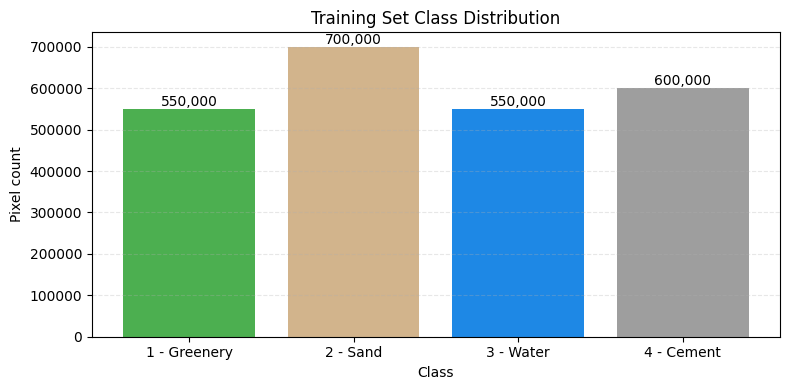

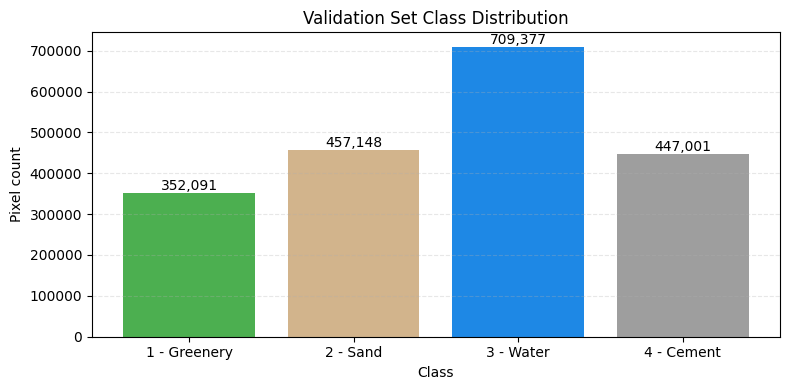

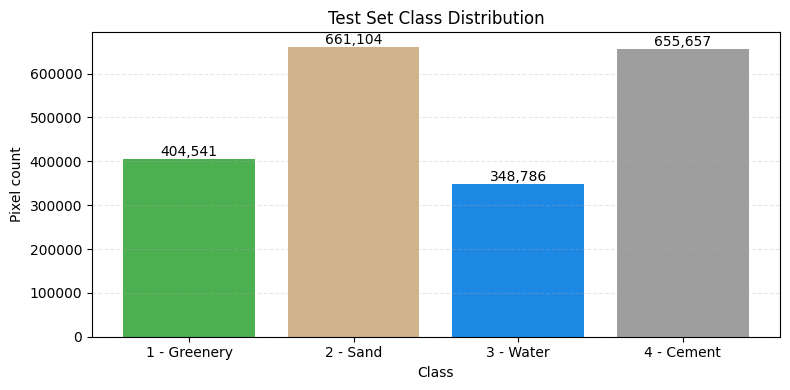

In [6]:
X_train_full, y_train_full, feature_names = build_dataset(train_meta, train=True)
X_val, y_val, _ = build_dataset(val_meta)
X_test, y_test, _ = build_dataset(test_meta)

print('Train full:', X_train_full.shape, count_by_class(y_train_full))
print('Val      :', X_val.shape, count_by_class(y_val))
print('Test     :', X_test.shape, count_by_class(y_test))

X_train, y_train, _ = sample_pixels(X_train_full, y_train_full, config.TRAIN_CAPS_CLASSIC)
print('Train sampled:', X_train.shape, count_by_class(y_train))
print('Val sampled  :', X_val.shape, count_by_class(y_val))
print('Test sampled :', X_test.shape, count_by_class(y_test))
plot_class_distribution(y_train, 'Training Set Class Distribution')
plot_class_distribution(y_val, 'Validation Set Class Distribution')
plot_class_distribution(y_test, 'Test Set Class Distribution')

In [7]:
y_train_enc = encode_labels(y_train)

model = XGBClassifier(
    n_estimators=700,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=2.0,
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=config.RANDOM_STATE,
)

model.fit(X_train, y_train_enc)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [8]:
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [9]:
model = pickle.load(open("model.pkl", "rb"))

===== Train =====
              precision    recall  f1-score   support

           1     0.9390    0.9432    0.9411    550000
           2     0.8985    0.8628    0.8803    700000
           3     0.9929    0.9937    0.9933    550000
           4     0.8085    0.8421    0.8249    600000

    accuracy                         0.9060   2400000
   macro avg     0.9097    0.9104    0.9099   2400000
weighted avg     0.9069    0.9060    0.9063   2400000

Confusion Matrix:
 [[518737   3325   2124  25814]
 [  2539 603993    455  93013]
 [  2419    199 546531    851]
 [ 28726  64710   1314 505250]]
mIoU: 0.840924388401294
Per-class IoU: {'Greenery': 0.888729175375717, 'Sand': 0.7862096704910223, 'Water': 0.9867086242288673, 'Cement': 0.7020500835095695}


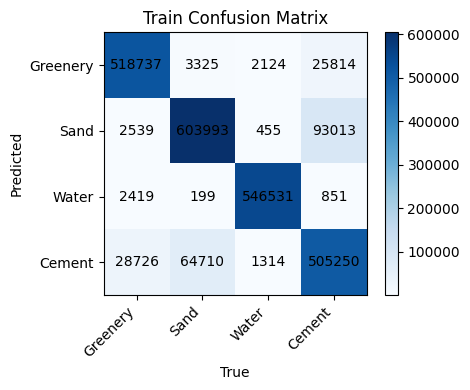

In [10]:
evaluate_split("Train", model, X_train, y_train)


===== Validation =====
              precision    recall  f1-score   support

           1     0.8786    0.9512    0.9135    352091
           2     0.8932    0.8791    0.8861    457148
           3     0.9930    0.9911    0.9920    709377
           4     0.8449    0.8061    0.8250    447001

    accuracy                         0.9158   1965617
   macro avg     0.9024    0.9069    0.9042   1965617
weighted avg     0.9156    0.9158    0.9153   1965617

Confusion Matrix:
 [[334922   2141   1556  13472]
 [  2580 401884   1292  51392]
 [  4511    516 703065   1285]
 [ 39187  45390   2118 360306]]
mIoU: 0.8306483633759042
Per-class IoU: {'Greenery': 0.8407330891710951, 'Sand': 0.7955027266698997, 'Water': 0.9842120661922914, 'Cement': 0.7021455714703303}


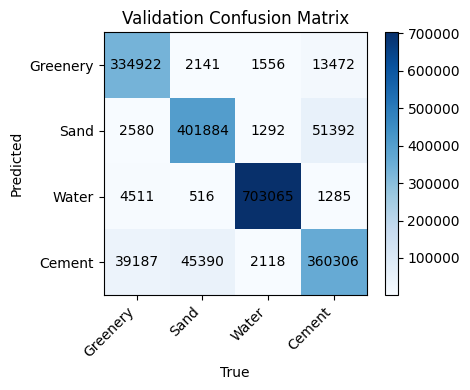

In [11]:
evaluate_split('Validation', model, X_val, y_val)

===== Test =====
              precision    recall  f1-score   support

           1     0.8956    0.9380    0.9163    404541
           2     0.8791    0.8239    0.8506    661104
           3     0.9880    0.9834    0.9857    348786
           4     0.8037    0.8330    0.8181    655657

    accuracy                         0.8760   2070088
   macro avg     0.8916    0.8946    0.8927   2070088
weighted avg     0.8768    0.8760    0.8759   2070088

Confusion Matrix:
 [[379464   2660   2280  20137]
 [  2954 544676    949 112525]
 [  4264    748 342996    778]
 [ 37027  71520    920 546190]]
mIoU: 0.8123902668282408
Per-class IoU: {'Greenery': 0.8455343972405557, 'Sand': 0.7400167384026781, 'Water': 0.9718390071826257, 'Cement': 0.6921709244871036}


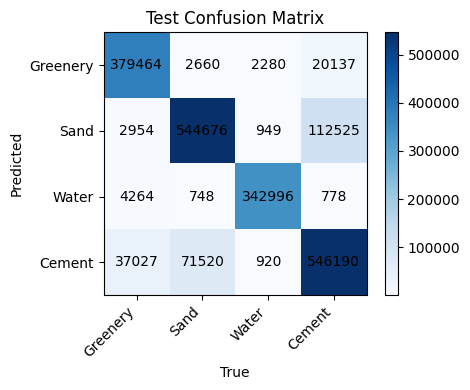

In [12]:
evaluate_split('Test', model, X_test, y_test)


In [13]:
importance_df = pd.DataFrame(
    {
        'feature': feature_names,
        'importance': model.feature_importances_,
    }
).sort_values('importance', ascending=False)

display(importance_df.head(20))

,feature,importance
8,B9,0.185592
24,awei_nsh,0.172986
36,red_blue_diff,0.157496
41,ndvi_mean_5,0.098315
11,B12,0.048205
3,B4,0.045060
39,ndvi_mean_3,0.039085
44,mndwi_std_3,0.033032
49,swir1_mean_3,0.027747
42,ndvi_std_5,0.022702


In [14]:
@np.errstate(divide='ignore', invalid='ignore')
def show_prediction(model, split_df, idx=0):
    row = split_df.iloc[idx]
    img, mask, pixel_valid = preprocess_img(row['img_path'], row['mask_path'])
    features, _ = extract_features(img)

    valid = pixel_valid & (mask != 0)
    pred_mask = np.zeros_like(mask, dtype=np.uint8)

    if np.any(valid):
        X = features[:, valid].T.astype(np.float32)
        pred_mask[valid] = decode_labels(model.predict(X))

    rgb = np.transpose(img[[3, 2, 1]], (1, 2, 0))
    rgb = np.clip(rgb * 3.0, 0, 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title('RGB')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='tab10', vmin=0, vmax=4)
    plt.title('Ground Truth')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap='tab10', vmin=0, vmax=4)
    plt.title('Prediction')
    plt.axis('off')

    plt.show()

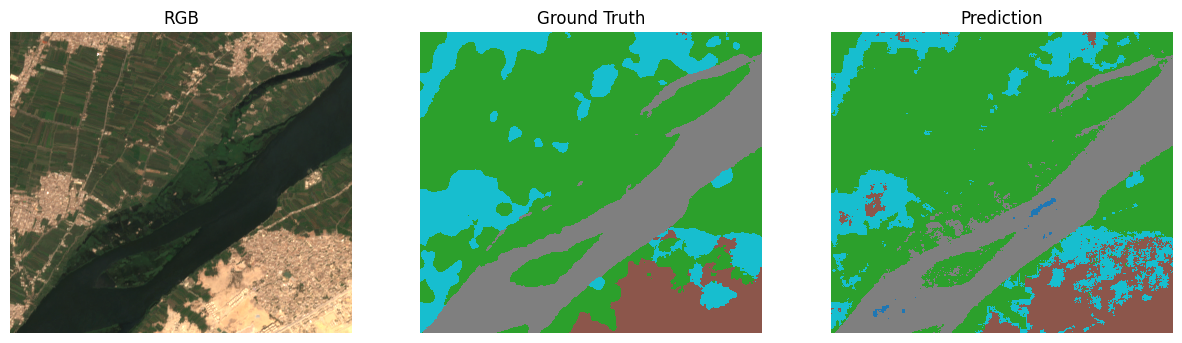

In [15]:
show_prediction(model, test_meta, idx=3)